In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = "../data/"

orders = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv")
reviews = pd.read_csv(DATA_PATH + "olist_order_reviews_dataset.csv")
customers = pd.read_csv(DATA_PATH + "olist_customers_dataset.csv")
products = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
translations = pd.read_csv(DATA_PATH + "product_category_name_translation.csv")

print("Orders:", orders.shape)
print("Reviews:", reviews.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Translations:", translations.shape)

Orders: (99441, 8)
Reviews: (99224, 7)
Customers: (99441, 5)
Products: (32951, 9)
Translations: (71, 2)


In [15]:
# Merge orders with reviews
df = orders.merge(reviews, on="order_id", how="left")

# Merge with customers
df = df.merge(customers, on="customer_id", how="left")

print(df.shape)

df.head()

(99992, 18)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,8d5266042046a06655c8db133d120ba5,4.0,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,e73b67b67587f7644d5bd1a52deb1b01,5.0,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,359d03e676b3c069f62cadba8dd3f6e8,5.0,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03 00:00:00,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,e50934924e227544ba8246aeb3770dd4,5.0,NaN,NaN,2018-02-17 00:00:00,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [16]:
# Keep only delivered orders for delivery analysis
df = df[df["order_status"] == "delivered"].copy()

print(df["order_status"].value_counts())
print(df.shape)

order_status
delivered    97007
Name: count, dtype: int64
(97007, 18)


In [18]:
# Convert date columns to datetime

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
    "review_answer_timestamp"
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors="coerce")

df[date_cols].dtypes

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
review_creation_date             datetime64[ns]
review_answer_timestamp          datetime64[ns]
dtype: object

In [20]:
# Calculate delivery delay in days

df["delay_days"] = (
    df["order_delivered_customer_date"]
    - df["order_estimated_delivery_date"]
).dt.days

df[[
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "delay_days"
]].head()

,order_delivered_customer_date,order_estimated_delivery_date,delay_days
0,2017-10-10 21:25:13,2017-10-18,-8.0
1,2018-08-07 15:27:45,2018-08-13,-6.0
2,2018-08-17 18:06:29,2018-09-04,-18.0
3,2017-12-02 00:28:42,2017-12-15,-13.0
4,2018-02-16 18:17:02,2018-02-26,-10.0


In [21]:
# Classify delivery performance

df["delivery_status"] = np.where(
    df["delay_days"] <= 0,
    "On Time",
    np.where(
        df["delay_days"] <= 5,
        "Late",
        "Super Late"
    )
)

df[["delay_days", "delivery_status"]].head(10)

,delay_days,delivery_status
0,-8.0,On Time
1,-6.0,On Time
2,-18.0,On Time
3,-13.0,On Time
4,-10.0,On Time
5,-6.0,On Time
7,-12.0,On Time
8,-32.0,On Time
9,-7.0,On Time
10,-9.0,On Time


In [22]:
# Percentage of orders in each delivery category

delivery_summary = (
    df["delivery_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(delivery_summary)

delivery_status
On Time       93.23
Super Late     3.91
Late           2.86
Name: proportion, dtype: float64


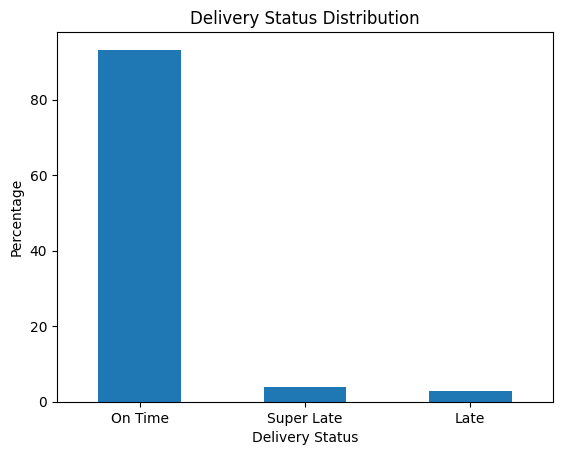

In [23]:
# Plot delivery status distribution

delivery_summary.plot(kind="bar")

plt.title("Delivery Status Distribution")
plt.xlabel("Delivery Status")
plt.ylabel("Percentage")
plt.xticks(rotation=0)

plt.show()

In [24]:
# Percentage of delayed orders by state

state_late_pct = (
    df.assign(is_late=df["delivery_status"] != "On Time")
      .groupby("customer_state")["is_late"]
      .mean()
      .mul(100)
      .round(2)
      .sort_values(ascending=False)
)

print(state_late_pct.head(10))

customer_state
AL    21.45
MA    17.34
SE    15.22
PI    13.84
CE    13.81
BA    12.22
RR    12.20
RJ    12.10
PA    11.13
ES    10.68
Name: is_late, dtype: float64


In [25]:
# Average review score by delivery status

review_impact = (
    df.groupby("delivery_status")["review_score"]
    .mean()
    .round(2)
)

print(review_impact)

delivery_status
Late          2.99
On Time       4.29
Super Late    1.75
Name: review_score, dtype: float64


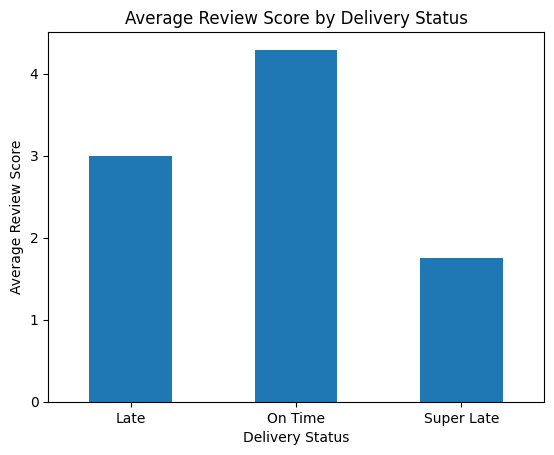

In [26]:
# Plot review score by delivery status

review_impact.plot(kind="bar")

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")
plt.xticks(rotation=0)

plt.show()

In [28]:
translations.head()


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [10]:
df.to_csv("../outputs/olist_dashboard_data.csv", index=False)

print("Export complete.")

Export complete.
